In [3]:
import pandas as pd
import numpy as np
import torch
import pickle
from typing import Optional, List, Dict, Tuple
from pathlib import Path
import json


In [29]:
def load_medication_data(parquet_path: str) -> pd.DataFrame:
    """
    Load medication data for context tensor creation.

    Attempts parquet first (regardless of file extension), then falls back to
    pandas pickle, raw pickle, and a safe torch.load probe. Normalizes schema
    to include a 'rate/weight_normalized' column by mapping from common
    alternatives when needed.
    """
    print(f"Loading medication data from {parquet_path}...")

    df: Optional[pd.DataFrame] = None
    loaders_tried: List[str] = []

    # Always try parquet first; many .bin files are parquet saved with a custom extension
    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e_parquet:
        loaders_tried.append(f"parquet:{e_parquet}")
        # Try pandas' pickle reader
        try:
            df = pd.read_pickle(parquet_path)
        except Exception as e_pd_pickle:
            loaders_tried.append(f"pd.read_pickle:{e_pd_pickle}")
            # Try raw pickle.load
            try:
                with open(parquet_path, 'rb') as f:
                    obj = pickle.load(f)
                if isinstance(obj, pd.DataFrame):
                    df = obj
                else:
                    raise TypeError("pickled object was not a pandas DataFrame")
            except Exception as e_raw_pickle:
                loaders_tried.append(f"pickle.load:{e_raw_pickle}")
                # Try a lightweight torch.load probe (in case the file was saved via torch)
                try:
                    import torch as _torch
                    obj = _torch.load(parquet_path, map_location="cpu")
                    if isinstance(obj, pd.DataFrame):
                        df = obj
                    elif isinstance(obj, dict) and 'data' in obj and isinstance(obj['data'], pd.DataFrame):
                        df = obj['data']
                    else:
                        raise TypeError("torch file did not contain a pandas DataFrame")
                except Exception as e_torch:
                    loaders_tried.append(f"torch.load:{e_torch}")

    if df is None:
        raise ValueError(
            f"Failed to load medication data from {parquet_path}. Tried: {loaders_tried}"
        )

    # Normalize column names where possible (map common variants to canonical)
    cols_lower_map = {c.lower(): c for c in df.columns}

    def _ensure_column(df_in: pd.DataFrame, canonical: str, candidates: List[str]) -> None:
        for cand in candidates:
            cand_lower = cand.lower()
            if cand_lower in cols_lower_map:
                src = cols_lower_map[cand_lower]
                if src != canonical and canonical not in df_in.columns:
                    df_in.rename(columns={src: canonical}, inplace=True)
                return

    _ensure_column(df, 'hadm_id', ['hadm_id', 'HADM_ID'])
    _ensure_column(df, 'start_time', ['start_time', 'START_TIME', 'STARTTIME'])
    _ensure_column(df, 'end_time', ['end_time', 'END_TIME', 'ENDTIME'])
    _ensure_column(df, 'item_label', ['item_label', 'ITEM_LABEL'])

    # Normalize rate column -> create 'rate/weight_normalized' if missing
    rate_canonical = 'rate/weight_normalized'
    if rate_canonical not in df.columns:
        # Candidates: common variants and fuzzy contains('rate') & contains('weight')
        candidate_order = [
            'rate_weight_normalized',
            'rate_per_kg',
            'rate_per_weight',
            'rate/weight',
            'rate',
            'RATE',
        ]
        picked_src: Optional[str] = None

        for cand in candidate_order:
            if cand in df.columns:
                picked_src = cand
                break
            if cand.lower() in cols_lower_map:
                picked_src = cols_lower_map[cand.lower()]
                break

        if picked_src is None:
            # Fuzzy search: any col name containing both 'rate' and 'weight'
            fuzzy = [c for c in df.columns if ('rate' in c.lower() and 'weight' in c.lower())]
            if len(fuzzy) > 0:
                picked_src = fuzzy[0]

        if picked_src is not None:
            df[rate_canonical] = pd.to_numeric(df[picked_src], errors='coerce')
        else:
            # As a last resort, if a plain 'rate' exists, use it
            if 'rate' in df.columns:
                df[rate_canonical] = pd.to_numeric(df['rate'], errors='coerce')

    # Validate required columns
    required_cols = ['hadm_id', 'start_time', 'end_time', 'item_label', rate_canonical]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            "Missing required medication columns: {}. Available: {}".format(
                missing_cols, list(df.columns)
            )
        )

    # Ensure datetime types and make tz-naive (UTC)
    if not pd.api.types.is_datetime64_any_dtype(df['start_time']):
        df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
    if not pd.api.types.is_datetime64_any_dtype(df['end_time']):
        df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
    if pd.api.types.is_datetime64tz_dtype(df['start_time']):
        try:
            df['start_time'] = df['start_time'].dt.tz_convert('UTC').dt.tz_localize(None)
        except Exception:
            df['start_time'] = df['start_time'].dt.tz_localize(None)
    if pd.api.types.is_datetime64tz_dtype(df['end_time']):
        try:
            df['end_time'] = df['end_time'].dt.tz_convert('UTC').dt.tz_localize(None)
        except Exception:
            df['end_time'] = df['end_time'].dt.tz_localize(None)

    print(f"Loaded {len(df)} medication events")
    # Clean meds: remove Esmolol; cap each medication at mean + 4*std (per item)
    if 'item_label' in df.columns:
        # Drop Esmolol (case-insensitive)
        mask_esmo = df['item_label'].str.lower() == 'esmolol'
        if mask_esmo.any():
            df = df.loc[~mask_esmo].copy()
            print(f"Removed {int(mask_esmo.sum())} Esmolol rows")

        # Ensure numeric
        df[rate_canonical] = pd.to_numeric(df[rate_canonical], errors='coerce')

        # Compute per-medication caps at mean + 4*std
        stats = df.groupby('item_label')[rate_canonical].agg(['mean', 'std'])
        stats['cap'] = stats['mean'] + 4.0 * stats['std']

        # Merge caps and clip
        df = df.merge(stats['cap'].rename('___cap'), left_on='item_label', right_index=True, how='left')
        before = df[rate_canonical]
        df[rate_canonical] = before.clip(lower=0.0, upper=df['___cap'])
        num_clipped = int((before > df['___cap']).sum())
        df.drop(columns=['___cap'], inplace=True)
        if num_clipped > 0:
            print(f"Capped {num_clipped} medication rows at mean+4*std per item_label")

    return df

In [30]:
medications_df = load_medication_data('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin')

Loading medication data from /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin...
Loaded 32410 medication events
Removed 157 Esmolol rows


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_3602124/223475029.py:120: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['start_time']):
/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_3602124/223475029.py:125: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['end_time']):


Capped 107 medication rows at mean+4*std per item_label


In [37]:

def load_waveforms_data(parquet_path: str) -> pd.DataFrame:
    """
    Load waveforms data for context tensor creation.
    """
    print(f"Loading waveforms data from {parquet_path}...")
    df = pd.read_parquet(parquet_path)

    # Ensure absolute_timestamp is datetime and tz-naive (UTC)
    if not pd.api.types.is_datetime64_any_dtype(df['absolute_timestamp']):
        df['absolute_timestamp'] = pd.to_datetime(df['absolute_timestamp'], errors='coerce')
    # If tz-aware, convert to UTC then drop tz
    if pd.api.types.is_datetime64tz_dtype(df['absolute_timestamp']):
        try:
            df['absolute_timestamp'] = df['absolute_timestamp'].dt.tz_convert('UTC').dt.tz_localize(None)
        except Exception:
            # If tz_convert fails (ambiguous/non-existent), just drop tz
            df['absolute_timestamp'] = df['absolute_timestamp'].dt.tz_localize(None)

    # Check for required physio columns
    required_physio = ['ABP MEAN_z', 'CVP_z', 'HR_z', 'RESP_z']
    available_physio = [col for col in required_physio if col in df.columns]
    missing_physio = [col for col in required_physio if col not in df.columns]

    print(f"Available physio measurements: {available_physio}")
    if missing_physio:
        print(f"Missing physio measurements: {missing_physio}")

    return df


In [39]:
waveforms_df = load_waveforms_data('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/smoothed_numerics.bin')

Loading waveforms data from /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/smoothed_numerics.bin...
Available physio measurements: ['ABP MEAN_z', 'CVP_z', 'HR_z', 'RESP_z']


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_3602124/1145269912.py:12: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['absolute_timestamp']):


In [40]:
waveforms_df.head()

,hadm_id,record_name,absolute_timestamp,ABP MEAN,NBP MEAN,CVP,HR,RESP,record_start_time,record_end_time,icu_admission_time,time_seconds,ABP MEAN_z,CVP_z,HR_z,RESP_z
0,100031,p006892-2140-11-11-22-04n,2140-11-11 22:04:00.056,NaN,NaN,9.60,91.0,12.0,2140-11-11 22:04:00.056,2140-11-15 20:45:00.055999,2140-11-11 20:22:38,0,NaN,0.137797,0.264305,-1.414881
1,100031,p006892-2140-11-11-22-04n,2140-11-11 22:04:10.056,NaN,NaN,9.75,91.0,12.0,2140-11-11 22:04:00.056,2140-11-15 20:45:00.055999,2140-11-11 20:22:38,10,NaN,0.156670,0.264305,-1.414881
2,100031,p006892-2140-11-11-22-04n,2140-11-11 22:04:20.056,NaN,NaN,9.90,91.0,12.0,2140-11-11 22:04:00.056,2140-11-15 20:45:00.055999,2140-11-11 20:22:38,20,NaN,0.175543,0.264305,-1.414881
3,100031,p006892-2140-11-11-22-04n,2140-11-11 22:04:30.056,NaN,NaN,10.05,91.0,12.0,2140-11-11 22:04:00.056,2140-11-15 20:45:00.055999,2140-11-11 20:22:38,30,NaN,0.194416,0.264305,-1.414881
4,100031,p006892-2140-11-11-22-04n,2140-11-11 22:04:40.056,NaN,NaN,10.20,91.0,12.0,2140-11-11 22:04:00.056,2140-11-15 20:45:00.055999,2140-11-11 20:22:38,40,NaN,0.213289,0.264305,-1.414881


In [4]:
df_triggers = medications_df.dropna(subset=['action_cluster_id'])

In [5]:
df_triggers

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,...,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank,first,last,absolute_timestamp,wf_time_delta_s
3,5171,125124,221906,01-Drips,Continuous Med,2171-10-16 08:39:00+00:00,2171-10-16 08:56:00+00:00,0.040033,mcg/kg/min,0.040033,...,0.060038,True,decrease,9.0,2.0,1.0,2171-10-16 07:57:41+00:00,2171-10-20 11:07:11+00:00,2171-10-16 08:39:01+00:00,1.0
4,5171,125124,221906,01-Drips,Continuous Med,2171-10-16 08:56:00+00:00,2171-10-16 09:35:00+00:00,0.080065,mcg/kg/min,0.080065,...,0.040033,True,increase,9.0,2.0,2.0,2171-10-16 07:57:41+00:00,2171-10-20 11:07:11+00:00,2171-10-16 08:56:01+00:00,1.0
10,5171,125124,221906,01-Drips,Continuous Med,2171-10-16 10:44:00+00:00,2171-10-16 11:56:00+00:00,0.080097,mcg/kg/min,0.080097,...,0.060060,True,increase,10.0,1.0,1.0,2171-10-16 07:57:41+00:00,2171-10-20 11:07:11+00:00,2171-10-16 10:44:01+00:00,1.0
12,5171,125124,225828,03-IV Fluid Bolus,Bolus,2171-10-16 11:36:00+00:00,2171-10-16 11:37:00+00:00,NaN,None,NaN,...,1.000000,True,bolus,11.0,1.0,1.0,2171-10-16 07:57:41+00:00,2171-10-20 11:07:11+00:00,2171-10-16 11:36:01+00:00,1.0
14,5171,125124,221906,01-Drips,Continuous Med,2171-10-16 12:20:00+00:00,2171-10-16 12:29:00+00:00,0.100164,mcg/kg/min,0.100164,...,0.070085,True,increase,12.0,3.0,1.0,2171-10-16 07:57:41+00:00,2171-10-20 11:07:11+00:00,2171-10-16 12:20:01+00:00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32404,99982,151454,221986,01-Drips,Continuous Med,2156-12-04 09:11:00+00:00,2156-12-05 05:56:00+00:00,0.125066,mcg/kg/min,0.125066,...,0.250000,True,decrease,29.0,1.0,1.0,2156-11-28 14:21:06+00:00,2156-12-05 12:09:36+00:00,2156-12-04 09:10:56+00:00,-4.0
32405,99982,151454,220864,04-Fluids (Colloids),Continuous IV,2156-12-04 11:26:00+00:00,2156-12-04 12:26:00+00:00,249.999990,mL/hour,3.511236,...,14.044943,True,decrease,30.0,1.0,1.0,2156-11-28 14:21:06+00:00,2156-12-05 12:09:36+00:00,2156-12-04 11:25:56+00:00,-4.0
32406,99982,151454,220862,04-Fluids (Colloids),Continuous IV,2156-12-04 18:02:00+00:00,2156-12-04 18:32:00+00:00,99.999996,mL/hour,1.404494,...,NaN,True,start,31.0,1.0,1.0,2156-11-28 14:21:06+00:00,2156-12-05 12:09:36+00:00,2156-12-04 18:01:56+00:00,-4.0
32408,99982,151454,221986,01-Drips,Continuous Med,2156-12-05 05:56:00+00:00,2156-12-05 08:14:00+00:00,0.250522,mcg/kg/min,0.250522,...,0.125066,True,increase,32.0,1.0,1.0,2156-11-28 14:21:06+00:00,2156-12-05 12:09:36+00:00,2156-12-05 05:55:56+00:00,-4.0


In [ ]:
patient_meds = 

In [7]:
example_randrop_tensor = torch.load('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/context_tensors_output/raindrop_context/rd_context_100098_65.pt', weights_only=True)

In [9]:
example_randrop_tensor[0]

tensor([[-0.4268,  0.9579,  0.4720, -0.1265,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0781,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  0.0000,  1.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  1.0000],
        [-0.4441,  0.9454,  0.4615, -0.1470,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0781,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  0.0000,  1.0000,  1.0000, 

In [2]:
import sys, os
import torch

# Allow imports from project modules
sys.path.append('/n/holylfs06/LABS/mzitnik_lab/Lab/rconci/Counterfactual_ICU/src_new/models')
from dataloaders.MIMIC_data import MIMICDataModule

# Configure data roots
data_root = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data'
icu_stays = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data/ICUSTAYS.csv'

# Build DataModule and fetch one training batch
dm = MIMICDataModule(
    data_root=data_root,
    icu_stays_path=icu_stays,
    batch_size=2,
    num_workers=0,
    random_state=42,
    max_samples=14,
    use_raindrop_context=True,
)
dm.setup('fit')
loader = dm.train_dataloader()

(rd_src, rd_times, rd_length, static_feats, ic_tensor, ic_mask_tensor, p_out_values, p_out_mask, t_Y, med_traj_values, med_traj_mask, med_traj_time_sec, med_tensors) = next(iter(loader))

print('Batch shapes:')
print('  rd_src:', rd_src.shape, 'rd_times:', rd_times.shape, 'rd_length:', rd_length.shape)
print('  static:', static_feats.shape)



[DEBUG] Limited to 14 samples for testing
Split 'train': 14 trajectories
Target trajectory split: 3458/741/742
Actual trajectory split: 3451/735/755
Trajectory percentages: 69.8%/14.9%/15.3%
[DEBUG] Limited to 14 samples for testing
Split 'val': 14 trajectories
Target trajectory split: 3458/741/742
Actual trajectory split: 3451/735/755
Trajectory percentages: 69.8%/14.9%/15.3%
Batch shapes:
  rd_src: torch.Size([2, 6, 52]) rd_times: torch.Size([2, 6]) rd_length: torch.Size([2])
  static: torch.Size([2, 15])


In [7]:
rd_src[0][0, :]

tensor([-1.0968,  0.2812,  0.4187,  0.3111,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0281,  0.0000,  0.0000,  0.0000,  0.0300,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000,
         0.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
         1.0000,  1.0000,  1.0000,  0.0000,  1.0000,  1.0000,  1.0000,  0.0000,
         1.0000,  1.0000,  1.0000,  1.0000])

In [8]:
# Build and run Raindrop encoder on the fetched batch
sys.path.append('/n/holylfs06/LABS/mzitnik_lab/Lab/rconci/Counterfactual_ICU/src_new/models')
from raindrop import Raindrop_v2

# Infer d_inp from rd_src last dim (half of it)
d_inp = rd_src.shape[-1] // 2
encoder_hidden_dim = 64
nlayers = 2
model = Raindrop_v2(
    d_inp=d_inp,
    d_model=encoder_hidden_dim,
    nhead=4,
    nhid=128,
    nlayers=nlayers,
    dropout=0.1,
    max_len=rd_src.shape[1],
    d_static=static_feats.shape[-1],
    output_dim=d_inp,  # not used directly in our wrapper
    global_structure=torch.ones(d_inp, d_inp),
    sensor_wise_mask=False,
    static=False,
    debug=False,
)

# Raindrop expects [T,B,2*d_inp], [T,B], lengths [B]
src = rd_src.permute(1,0,2)
times = rd_times.permute(1,0)
lengths = rd_length
with torch.no_grad():
    z, _, _ = model(src=src, static=None, times=times, lengths=lengths)
print('Temporal embedding shape:', z.shape)



/n/holylfs06/LABS/mzitnik_lab/Lab/rconci/micromamba/envs/cf_icu2/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[MASK DEBUG] Original mask creation:
  maxlen: 6, batch_size: 2
  lengths: tensor([6, 6])
  lengths shape: torch.Size([2])
[MASK DEBUG] After squeeze:
  Expected shape for transformer: [batch_size, seq_len] = [2, 6]
Temporal embedding shape: torch.Size([2, 68])


In [18]:
z

tensor([[ 0.2616, -1.9387,  0.5636, -0.5242, -0.5311, -0.3206,  0.1042, -0.6179,
         -0.2879,  0.9790,  1.2504,  0.1429, -1.0017,  0.7210, -0.0878,  0.8264,
         -0.3748, -0.4846, -0.1779,  0.0812, -0.4391,  0.7140,  0.3439, -0.1860,
         -0.5005,  0.2368, -0.5723, -0.6046,  0.2601, -0.5452,  0.4321,  0.4441,
         -0.1865, -0.1385,  0.2548, -0.5720, -0.5431,  0.2318,  0.9205, -0.2548,
         -1.4310,  0.6822,  1.8894,  0.2735, -0.3735, -0.1954,  1.1234,  0.3565,
          0.1673, -0.3215, -1.0311, -1.1548, -1.6030, -1.0151, -1.1822, -0.9840,
          0.0262, -0.8600, -0.0873, -1.5011,  0.9361,  0.8586,  0.8997,  1.6790,
          0.6594,  1.4611,  1.0278,  1.8212],
        [ 0.3008, -2.0333,  0.5655, -0.5209, -0.5649, -0.2771,  0.4614, -0.7312,
         -0.2296,  0.8950,  1.1547,  0.1077, -1.0477,  0.8220, -0.0217,  0.7681,
         -0.3263, -0.3549, -0.2177,  0.0657, -0.3448,  0.7401,  0.3302, -0.2832,
         -0.6367,  0.2162, -0.5668, -0.6943,  0.1889, -0.4540, 

## MED TENSORS 

In [28]:
import torch 
med_sample = torch.load('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output/med_tensor_100098_55.pt', weights_only=True)

In [29]:
len(med_sample)

6

In [30]:
med_sample

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,   90.,
          100.,  110.,  120.,  130.,  140.,  150.,  160.,  170.,  180.,  190.,
          200.,  210.,  220.,  230.,  240.,  250.,  260.,  270.,  280.,  290.,
          300.,  310.,  320.,  330.,  340.,  350.,  360.,  370.,  380.,  390.,
          400.,  410.,  420.,  430.,  440.,  450.,  460.,  470.,  480.,  490.,
          500.,  510.,  520.,  530.,  540.,  550.,  560.,  570.,  580.,  590.,
  

In [31]:
med_sample[-1].sum()

tensor(2640.)

In [32]:
22*120

2640

## RAINDROP CONTEXT

In [33]:

rd_context_sample = torch.load('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/context_tensors_output/raindrop_context/rd_context_100098_53.pt', weights_only=True)


In [ ]:
"rd_src": rd_src,  # [T_ctx, 2*d_inp]
"rd_times": rd_times,  # [T_ctx]
"rd_length": rd_length,  # scalar length

In [37]:
rd_context_sample[0][0,:27]

tensor([ 0.0363, -0.0551,  0.7259, -0.0696,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0844,  0.0000,  0.0000,  0.0000,  0.0901,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000])

In [1]:
import os
import pickle
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm


def load_and_prepare_data(parquet_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load the mv_filtered_10min.parquet file and prepare it for processing.
    Returns both the full dataset and the filtered dataset for trajectory identification.
    """
    print(f"Loading data from {parquet_path}...")
    df_full = pd.read_parquet(parquet_path)

    # Ensure start_time is datetime
    if not pd.api.types.is_datetime64_any_dtype(df_full["start_time"]):
        df_full["start_time"] = pd.to_datetime(df_full["start_time"])

    print(f"Loaded {len(df_full)} total medication rows")
    print(f"Unique hadm_ids: {df_full['hadm_id'].nunique()}")
    print(f"Unique item_labels: {df_full['item_label'].nunique()}")

    # Create filtered dataset for trajectory identification (only non-NaN action_cluster_id)
    df_triggers = df_full.dropna(subset=["action_cluster_id"])

    print(
        f"Rows with action_cluster_id (for trajectory identification): {len(df_triggers)}"
    )
    print(f"Unique action_cluster_ids: {df_triggers['action_cluster_id'].nunique()}")

    return df_full, df_triggers


def identify_trajectories(
    df_full: pd.DataFrame,
    df_triggers: pd.DataFrame,
    trajectory_duration_minutes: int = 20,
) -> Dict:
    """
    Group by hadm_id and action_cluster_id to identify trajectories.
    Each trajectory lasts trajectory_duration_minutes OR until the start of the next action_cluster_id.
    """
    print("Identifying trajectories and calculating trajectory windows...")

    trajectories = {}

    # First, get all action_cluster_ids per hadm_id with their t0 times
    action_starts = (
        df_triggers.groupby(["hadm_id", "action_cluster_id"])["start_time"]
        .min()
        .reset_index()
    )
    action_starts.columns = ["hadm_id", "action_cluster_id", "t0_time"]

    # Sort by hadm_id and t0_time to find next action starts
    action_starts = action_starts.sort_values(["hadm_id", "t0_time"])

    print(f"Found {len(action_starts)} unique action_cluster_ids across all patients")

    # For each hadm_id, determine trajectory end times
    for hadm_id in tqdm(action_starts["hadm_id"].unique(), desc="Processing patients"):
        patient_actions = action_starts[action_starts["hadm_id"] == hadm_id].copy()

        for idx, row in patient_actions.iterrows():
            action_cluster_id = row["action_cluster_id"]
            t0_time = row["t0_time"]

            # Calculate trajectory end time
            # Option 1: configurable minutes after t0
            end_time_20min = t0_time + pd.Timedelta(minutes=trajectory_duration_minutes)

            # Option 2: Start of next action_cluster_id
            next_actions = patient_actions[patient_actions["t0_time"] > t0_time]
            if len(next_actions) > 0:
                next_action_start = next_actions["t0_time"].min()
                trajectory_end_time = min(end_time_20min, next_action_start)
            else:
                trajectory_end_time = end_time_20min

            # Get all data for this patient within the trajectory window
            patient_data = df_full[df_full["hadm_id"] == hadm_id].copy()
            trajectory_data = patient_data[
                (patient_data["end_time"] > t0_time)  # Still ongoing at/after t0
                & (
                    patient_data["start_time"] < trajectory_end_time
                )  # Starts before trajectory ends
            ]

            # Store trajectory info
            traj_key = f"{hadm_id}_{int(action_cluster_id)}"
            trajectories[traj_key] = {
                "hadm_id": hadm_id,
                "action_cluster_id": action_cluster_id,
                "t0_time": t0_time,
                "trajectory_end_time": trajectory_end_time,
                "duration_minutes": (trajectory_end_time - t0_time).total_seconds()
                / 60,
                "data": trajectory_data,
            }

    print(f"Created {len(trajectories)} trajectories")

    # Print some statistics about trajectory durations
    durations = [t["duration_minutes"] for t in trajectories.values()]
    print("Trajectory duration statistics:")
    print(f"  Mean: {np.mean(durations):.2f} minutes")
    print(f"  Std: {np.std(durations):.2f} minutes")
    print(f"  Min: {np.min(durations):.2f} minutes")
    print(f"  Max: {np.max(durations):.2f} minutes")
    print(
        f"  Full {trajectory_duration_minutes}min trajectories: {sum(1 for d in durations if d >= (trajectory_duration_minutes - 0.1))}"
    )
    print(
        f"  Truncated trajectories: {sum(1 for d in durations if d < (trajectory_duration_minutes - 0.1))}"
    )

    return trajectories


def create_time_grid(
    trajectories: Dict,
    interval_seconds: int = 10,
    trajectory_duration_minutes: int = 20,
) -> Dict:
    """
    Create time grid parameters using the configured maximum forward duration.
    """
    print("Creating time grid parameters...")

    # Maximum trajectory duration is configurable (default 20 minutes)
    max_duration_seconds = trajectory_duration_minutes * 60
    n_intervals = int(np.ceil(max_duration_seconds / interval_seconds))

    # Verify this covers all trajectories
    actual_max_duration = (
        max(traj["duration_minutes"] for traj in trajectories.values()) * 60
    )

    print(
        f"Fixed trajectory duration: {max_duration_seconds} seconds ({trajectory_duration_minutes} minutes)"
    )
    print(f"Actual max trajectory duration: {actual_max_duration:.1f} seconds")
    print(
        f"Time grid will have {n_intervals} intervals of {interval_seconds} seconds each"
    )

    return {
        "n_intervals": n_intervals,
        "interval_seconds": interval_seconds,
        "max_duration": max_duration_seconds,
    }


def process_single_trajectory(
    traj_key: str,
    traj_info: Dict,
    item_labels: List[str],
    n_intervals: int,
    interval_seconds: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Process a single trajectory and create medication tensor.
    Only includes data within the trajectory window (t0 to trajectory_end_time).

    Returns:
        values_array: (n_intervals, n_medications) array of medication rates
        mask_array: (n_intervals, n_medications) array indicating data presence
    """
    data = traj_info["data"]
    t0_time = traj_info["t0_time"]
    trajectory_end_time = traj_info["trajectory_end_time"]

    # Initialize arrays
    n_medications = len(item_labels)
    values_array = np.zeros((n_intervals, n_medications), dtype=np.float32)
    mask_array = np.zeros((n_intervals, n_medications), dtype=np.float32)

    # Create item_label to index mapping
    item_to_idx = {item: idx for idx, item in enumerate(item_labels)}

    # Calculate the trajectory duration in intervals
    trajectory_duration_seconds = (trajectory_end_time - t0_time).total_seconds()
    max_interval_for_trajectory = min(
        n_intervals, int(np.ceil(trajectory_duration_seconds / interval_seconds))
    )

    # Process each medication type separately to handle overlaps correctly
    for item_label in item_labels:
        if item_label not in item_to_idx:
            continue

        item_idx = item_to_idx[item_label]

        # Get all infusions for this medication, sorted by start_time
        item_infusions = data[data["item_label"] == item_label].sort_values(
            "start_time"
        )

        for _, row in item_infusions.iterrows():
            # Get rate value
            rate_value = 0.0
            for rate_col in ["rate/weight_normalized"]:
                if rate_col in row and pd.notna(row[rate_col]):
                    rate_value = float(row[rate_col])
                    break

            if rate_value == 0.0:
                continue

            # Clip infusion to trajectory window
            effective_start = max(t0_time, row["start_time"])
            effective_end = min(trajectory_end_time, row["end_time"])

            # Convert to intervals (round down start, round up end)
            start_seconds = (effective_start - t0_time).total_seconds()
            end_seconds = (effective_end - t0_time).total_seconds()

            start_idx = int(start_seconds // interval_seconds)  # Round down
            end_idx = int(np.ceil(end_seconds / interval_seconds))  # Round up

            # Fill all intervals in range (most recent wins due to sort order)
            for time_idx in range(start_idx, end_idx):
                if 0 <= time_idx < max_interval_for_trajectory:
                    values_array[time_idx, item_idx] = rate_value
                    mask_array[time_idx, item_idx] = 1.0

    return values_array, mask_array


def save_trajectory_tensor(
    traj_key: str,
    values_array: np.ndarray,
    mask_array: np.ndarray,
    n_intervals: int,
    interval_seconds: int,
    output_dir: Path,
) -> str:
    """
    Save a trajectory tensor to disk.
    """
    # Create time arrays
    time_seconds = np.arange(n_intervals) * interval_seconds
    time_hours = time_seconds / 3600.0

    # Convert to tensors
    values_tensor = torch.from_numpy(values_array).float()
    mask_tensor = torch.from_numpy(mask_array).float()
    time_seconds_tensor = torch.from_numpy(time_seconds).float()
    time_hours_tensor = torch.from_numpy(time_hours).float()

    # Compute med context per time step: for each med, [last_rate, recency]
    # last_idx_plus1 via cumulative max of valid indices (1-based to keep 0 as sentinel)
    time_idx = np.arange(n_intervals, dtype=np.int64)
    valid = (mask_array > 0).astype(np.int64)
    valid_idxs = np.where(valid > 0, time_idx[None, :].T + 1, 0)  # [T, M]
    last_idx_plus1 = np.maximum.accumulate(valid_idxs, axis=0)
    has_valid = last_idx_plus1 > 0
    last_idx = np.clip(last_idx_plus1 - 1, 0, n_intervals - 1)
    # Gather last rates per time,med
    rows = last_idx
    cols = np.tile(np.arange(values_array.shape[1])[None, :], (n_intervals, 1))
    last_rates = values_array[rows, cols]
    # Compute recency in seconds relative to last valid time
    t_grid = (time_idx[:, None] * interval_seconds).astype(np.float32)
    last_times = (last_idx.astype(np.float32) * float(interval_seconds))
    time_since = t_grid - last_times
    recency = np.clip(time_since / 1200.0 - 1.0 / 1200.0, a_min=0.0, a_max=None)
    # Defaults where no valid data yet
    last_rates = np.where(has_valid, last_rates, 0.0).astype(np.float32)
    recency = np.where(has_valid, recency, 1.0).astype(np.float32)
    # Interleave per-med [rate, recency]
    med_context = np.stack([last_rates, recency], axis=-1)  # [T, M, 2]
    med_context = med_context.reshape(n_intervals, -1)  # [T, 2*M]

    # Create filename
    filename = f"med_tensor_{traj_key}.pt"
    filepath = output_dir / filename

    # Save tensor
    med_context_tensor = torch.from_numpy(med_context).float()

    # Backward compatible: append med_context as 6th item
    torch.save(
        (
            values_tensor,
            mask_tensor,
            time_seconds_tensor,
            time_hours_tensor,
            n_intervals,
            med_context_tensor,
        ),
        filepath,
    )

    return str(filepath)


def create_med_tensors_from_parquet(
    parquet_path: str,
    output_dir: str = "./med_tensors_output",
    interval_seconds: int = 10,
    trajectory_duration_minutes: int = 20,
    n_workers: int = 1,
) -> Dict:
    """
    Main function to create med_tensors from mv_filtered_10min.parquet file.

    Args:
        parquet_path: Path to the mv_filtered_10min.parquet file
        output_dir: Directory to save the tensor files
        interval_seconds: Time interval in seconds (default: 10)
        n_workers: Number of parallel workers (not implemented yet, placeholder)

    Returns:
        Dictionary with metadata about created tensors
    """

    # Create output directory
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # Step 1: Load and prepare data
    df_full, df_triggers = load_and_prepare_data(parquet_path)

    # Step 2: Identify trajectories using trigger data, but get all meds from full data
    trajectories = identify_trajectories(
        df_full,
        df_triggers,
        trajectory_duration_minutes=trajectory_duration_minutes,
    )

    # Step 3: Get unique item labels from FULL dataset (all medications)
    unique_item_labels = sorted(df_full["item_label"].unique().tolist())
    print(f"Found {len(unique_item_labels)} unique item labels:")
    for i, label in enumerate(unique_item_labels):
        print(f"  {i}: {label}")

    # Step 4: Create time grid parameters respecting configurable forward duration
    grid_params = create_time_grid(
        trajectories,
        interval_seconds,
        trajectory_duration_minutes=trajectory_duration_minutes,
    )
    n_intervals = grid_params["n_intervals"]

    # Step 5: Process each trajectory
    print(f"\nProcessing {len(trajectories)} trajectories...")

    trajectory_metadata = {}
    saved_files = []

    for traj_key, traj_info in tqdm(trajectories.items(), desc="Creating tensors"):
        # Process trajectory
        values_array, mask_array = process_single_trajectory(
            traj_key=traj_key,
            traj_info=traj_info,
            item_labels=unique_item_labels,
            n_intervals=n_intervals,
            interval_seconds=interval_seconds,
        )

        # Save tensor
        filepath = save_trajectory_tensor(
            traj_key=traj_key,
            values_array=values_array,
            mask_array=mask_array,
            n_intervals=n_intervals,
            interval_seconds=interval_seconds,
            output_dir=output_path,
        )

        # Store metadata
        trajectory_metadata[traj_key] = {
            "hadm_id": traj_info["hadm_id"],
            "action_cluster_id": traj_info["action_cluster_id"],
            "t0_time": traj_info["t0_time"],
            "n_intervals": n_intervals,
            "interval_seconds": interval_seconds,
            "trajectory_end_time": traj_info["trajectory_end_time"],
            "duration_minutes": traj_info["duration_minutes"],
            "n_medications": len(unique_item_labels),
            "file_path": filepath,
            "has_data": np.any(mask_array > 0),
            "total_nonzero_values": int(np.sum(mask_array)),
        }

        saved_files.append(filepath)

    # Step 6: Save metadata
    metadata = {
        "trajectories": trajectory_metadata,
        "item_labels": unique_item_labels,
        "n_intervals": n_intervals,
        "interval_seconds": interval_seconds,
        "total_trajectories": len(trajectories),
        "created_at": datetime.now().isoformat(),
        "source_file": parquet_path,
    }

    metadata_file = output_path / "med_tensors_metadata.pkl"
    with open(metadata_file, "wb") as f:
        pickle.dump(metadata, f)

    # Step 7: Save summary statistics
    summary_stats = {
        "total_trajectories": len(trajectories),
        "total_tensor_files": len(saved_files),
        "unique_hadm_ids": df_triggers["hadm_id"].nunique(),
        "unique_action_cluster_ids": df_triggers["action_cluster_id"].nunique(),
        "unique_item_labels": len(unique_item_labels),
        "time_grid_intervals": n_intervals,
        "interval_seconds": interval_seconds,
        "max_duration_hours": grid_params["max_duration"] / 3600.0,
    }

    print("\n=== Summary ===")
    for key, value in summary_stats.items():
        print(f"{key}: {value}")

    print(f"\nTensor files saved to: {output_path}")
    print(f"Metadata saved to: {metadata_file}")

    return metadata


def load_and_inspect_tensor(tensor_path: str) -> None:
    """
    Load and inspect a saved tensor file.
    """
    print(f"Loading tensor from: {tensor_path}")

    values_tensor, mask_tensor, time_seconds_tensor, time_hours_tensor, n_intervals = (
        torch.load(tensor_path)
    )

    print(f"Values tensor shape: {values_tensor.shape}")
    print(f"Mask tensor shape: {mask_tensor.shape}")
    print(f"Time intervals: {n_intervals}")
    print(f"Duration: {time_hours_tensor[-1]:.2f} hours")
    print(f"Non-zero values: {torch.sum(mask_tensor).item()}")
    print(
        f"Medications with data: {torch.sum(torch.any(mask_tensor > 0, dim=0)).item()}"
    )


In [ ]:

def load_waveforms_data(parquet_path: str) -> pd.DataFrame:
    """
    Load waveforms data for context tensor creation.
    """
    print(f"Loading waveforms data from {parquet_path}...")
    df = pd.read_parquet(parquet_path)

    # Ensure absolute_timestamp is datetime and tz-naive (UTC)
    if not pd.api.types.is_datetime64_any_dtype(df["absolute_timestamp"]):
        df["absolute_timestamp"] = pd.to_datetime(
            df["absolute_timestamp"], errors="coerce"
        )
    # If tz-aware, convert to UTC then drop tz
    if pd.api.types.is_datetime64tz_dtype(df["absolute_timestamp"]):
        try:
            df["absolute_timestamp"] = (
                df["absolute_timestamp"].dt.tz_convert("UTC").dt.tz_localize(None)
            )
        except Exception:
            # If tz_convert fails (ambiguous/non-existent), just drop tz
            df["absolute_timestamp"] = df["absolute_timestamp"].dt.tz_localize(None)

    # Check for required physio columns
    required_physio = ["ABP MEAN_z", "CVP_z", "HR_z", "RESP_z"]
    available_physio = [col for col in required_physio if col in df.columns]
    missing_physio = [col for col in required_physio if col not in df.columns]

    print(f"Available physio measurements: {available_physio}")
    if missing_physio:
        print(f"Missing physio measurements: {missing_physio}")

    return df


In [2]:

def load_medication_data(parquet_path: str) -> pd.DataFrame:
    """
    Load medication data for context tensor creation.

    Attempts parquet first (regardless of file extension), then falls back to
    pandas pickle, raw pickle, and a safe torch.load probe. Normalizes schema
    to include a 'rate/weight_normalized' column by mapping from common
    alternatives when needed.
    """
    print(f"Loading medication data from {parquet_path}...")

    df: Optional[pd.DataFrame] = None
    loaders_tried: List[str] = []

    # Always try parquet first; many .bin files are parquet saved with a custom extension
    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e_parquet:
        loaders_tried.append(f"parquet:{e_parquet}")
        # Try pandas' pickle reader
        try:
            df = pd.read_pickle(parquet_path)
        except Exception as e_pd_pickle:
            loaders_tried.append(f"pd.read_pickle:{e_pd_pickle}")
            # Try raw pickle.load
            try:
                with open(parquet_path, "rb") as f:
                    obj = pickle.load(f)
                if isinstance(obj, pd.DataFrame):
                    df = obj
                else:
                    raise TypeError("pickled object was not a pandas DataFrame")
            except Exception as e_raw_pickle:
                loaders_tried.append(f"pickle.load:{e_raw_pickle}")
                # Try a lightweight torch.load probe (in case the file was saved via torch)
                try:
                    import torch as _torch

                    obj = _torch.load(parquet_path, map_location="cpu")
                    if isinstance(obj, pd.DataFrame):
                        df = obj
                    elif (
                        isinstance(obj, dict)
                        and "data" in obj
                        and isinstance(obj["data"], pd.DataFrame)
                    ):
                        df = obj["data"]
                    else:
                        raise TypeError("torch file did not contain a pandas DataFrame")
                except Exception as e_torch:
                    loaders_tried.append(f"torch.load:{e_torch}")

    if df is None:
        raise ValueError(
            f"Failed to load medication data from {parquet_path}. Tried: {loaders_tried}"
        )

    # Normalize column names where possible (map common variants to canonical)
    cols_lower_map = {c.lower(): c for c in df.columns}

    def _ensure_column(
        df_in: pd.DataFrame, canonical: str, candidates: List[str]
    ) -> None:
        for cand in candidates:
            cand_lower = cand.lower()
            if cand_lower in cols_lower_map:
                src = cols_lower_map[cand_lower]
                if src != canonical and canonical not in df_in.columns:
                    df_in.rename(columns={src: canonical}, inplace=True)
                return

    _ensure_column(df, "hadm_id", ["hadm_id", "HADM_ID"])
    _ensure_column(df, "start_time", ["start_time", "START_TIME", "STARTTIME"])
    _ensure_column(df, "end_time", ["end_time", "END_TIME", "ENDTIME"])
    _ensure_column(df, "item_label", ["item_label", "ITEM_LABEL"])

    # Normalize rate column -> create 'rate/weight_normalized' if missing
    rate_canonical = "rate/weight_normalized"
    if rate_canonical not in df.columns:
        # Candidates: common variants and fuzzy contains('rate') & contains('weight')
        candidate_order = [
            "rate_weight_normalized",
            "rate_per_kg",
            "rate_per_weight",
            "rate/weight",
            "rate",
            "RATE",
        ]
        picked_src: Optional[str] = None

        for cand in candidate_order:
            if cand in df.columns:
                picked_src = cand
                break
            if cand.lower() in cols_lower_map:
                picked_src = cols_lower_map[cand.lower()]
                break

        if picked_src is None:
            # Fuzzy search: any col name containing both 'rate' and 'weight'
            fuzzy = [
                c for c in df.columns if ("rate" in c.lower() and "weight" in c.lower())
            ]
            if len(fuzzy) > 0:
                picked_src = fuzzy[0]

        if picked_src is not None:
            df[rate_canonical] = pd.to_numeric(df[picked_src], errors="coerce")
        else:
            # As a last resort, if a plain 'rate' exists, use it
            if "rate" in df.columns:
                df[rate_canonical] = pd.to_numeric(df["rate"], errors="coerce")

    # Validate required columns
    required_cols = ["hadm_id", "start_time", "end_time", "item_label", rate_canonical]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            "Missing required medication columns: {}. Available: {}".format(
                missing_cols, list(df.columns)
            )
        )

    # Ensure datetime types and make tz-naive (UTC)
    if not pd.api.types.is_datetime64_any_dtype(df["start_time"]):
        df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
    if not pd.api.types.is_datetime64_any_dtype(df["end_time"]):
        df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
    if pd.api.types.is_datetime64tz_dtype(df["start_time"]):
        try:
            df["start_time"] = (
                df["start_time"].dt.tz_convert("UTC").dt.tz_localize(None)
            )
        except Exception:
            df["start_time"] = df["start_time"].dt.tz_localize(None)
    if pd.api.types.is_datetime64tz_dtype(df["end_time"]):
        try:
            df["end_time"] = df["end_time"].dt.tz_convert("UTC").dt.tz_localize(None)
        except Exception:
            df["end_time"] = df["end_time"].dt.tz_localize(None)

    print(f"Loaded {len(df)} medication events")
    # Clean meds: remove Esmolol; cap each medication at mean + 4*std (per item)
    if "item_label" in df.columns:
        # Drop Esmolol (case-insensitive)
        mask_esmo = df["item_label"].str.lower() == "esmolol"
        if mask_esmo.any():
            df = df.loc[~mask_esmo].copy()
            print(f"Removed {int(mask_esmo.sum())} Esmolol rows")

        # Ensure numeric
        df[rate_canonical] = pd.to_numeric(df[rate_canonical], errors="coerce")

        # Compute per-medication caps at mean + 4*std
        stats = df.groupby("item_label")[rate_canonical].agg(["mean", "std"])
        stats["cap"] = stats["mean"] + 4.0 * stats["std"]

        # Merge caps and clip
        df = df.merge(
            stats["cap"].rename("___cap"),
            left_on="item_label",
            right_index=True,
            how="left",
        )
        before = df[rate_canonical]
        df[rate_canonical] = before.clip(lower=0.0, upper=df["___cap"])
        num_clipped = int((before > df["___cap"]).sum())
        df.drop(columns=["___cap"], inplace=True)
        if num_clipped > 0:
            print(f"Capped {num_clipped} medication rows at mean+4*std per item_label")

    df_triggers = df.dropna(subset=["action_cluster_id"])
    return df, df_triggers

In [4]:
med_parquet_path = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin'
df_full, df_triggers = load_medication_data(med_parquet_path)

Loading medication data from /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin...
Loaded 32410 medication events
Removed 157 Esmolol rows
Capped 107 medication rows at mean+4*std per item_label


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2559637/3961926884.py:129: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df["start_time"]):
/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2559637/3961926884.py:136: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df["end_time"]):


In [5]:
trajectory_duration_minutes = 20
trajectories = identify_trajectories(
    df_full,
    df_triggers,
    trajectory_duration_minutes=trajectory_duration_minutes,
)

Identifying trajectories and calculating trajectory windows...
Found 4931 unique action_cluster_ids across all patients


Processing patients: 100%|██████████| 201/201 [00:08<00:00, 22.84it/s]

Created 4931 trajectories
Trajectory duration statistics:
  Mean: 19.99 minutes
  Std: 0.37 minutes
  Min: 7.00 minutes
  Max: 20.00 minutes
  Full 20min trajectories: 4923
  Truncated trajectories: 8


In [31]:
cols_to_keep=['hadm_id', 'item_id','start_time', 'end_time','item_label','trigger','rate/weight_normalized']
trajectories['100098_53']['data'][cols_to_keep]

,hadm_id,item_id,start_time,end_time,item_label,trigger,rate/weight_normalized
11754,100098,225158,2108-04-11 10:02:00,2108-04-12 21:44:00,NaCl 0.9%,False,0.078125
11767,100098,221906,2108-04-12 10:38:00,2108-04-12 13:17:00,Norepinephrine,False,0.090058
11768,100098,225158,2108-04-12 10:38:00,2108-04-12 13:17:00,NaCl 0.9%,False,0.084429
11769,100098,220862,2108-04-12 12:03:00,2108-04-12 13:03:00,Albumin 25%,True,1.562500


In [8]:
unique_item_labels = sorted(df_full["item_label"].unique().tolist())
print(f"Found {len(unique_item_labels)} unique item labels:")
for i, label in enumerate(unique_item_labels):
    print(f"  {i}: {label}")

Found 21 unique item labels:
  0: Albumin 25%
  1: Albumin 5%
  2: Calcium Gluconate
  3: Diltiazem
  4: Dopamine
  5: Epinephrine
  6: Fresh Frozen Plasma
  7: Hydralazine
  8: LR
  9: Labetalol
  10: Mannitol
  11: Milrinone
  12: NaCl 0.9%
  13: Nicardipine
  14: Nitroglycerin
  15: Nitroprusside
  16: Norepinephrine
  17: Packed Red Blood Cells
  18: Phenylephrine
  19: Sodium Bicarbonate 8.4%
  20: Vasopressin


In [17]:
interval_seconds = 10
grid_params = create_time_grid(
    trajectories,
    interval_seconds,
    trajectory_duration_minutes=trajectory_duration_minutes,
)
n_intervals = grid_params["n_intervals"]


data = trajectories['100098_53']['data']
t0_time = trajectories['100098_53']['t0_time']
trajectory_end_time = trajectories['100098_53']['trajectory_end_time']

item_labels = unique_item_labels
n_medications = len(unique_item_labels)
values_array = np.zeros((n_intervals, n_medications), dtype=np.float32)
mask_array = np.zeros((n_intervals, n_medications), dtype=np.float32)


Creating time grid parameters...
Fixed trajectory duration: 1200 seconds (20 minutes)
Actual max trajectory duration: 1200.0 seconds
Time grid will have 120 intervals of 10 seconds each


In [18]:
item_to_idx = {item: idx for idx, item in enumerate(item_labels)}

In [19]:
item_to_idx

{'Albumin 25%': 0,
 'Albumin 5%': 1,
 'Calcium Gluconate': 2,
 'Diltiazem': 3,
 'Dopamine': 4,
 'Epinephrine': 5,
 'Fresh Frozen Plasma': 6,
 'Hydralazine': 7,
 'LR': 8,
 'Labetalol': 9,
 'Mannitol': 10,
 'Milrinone': 11,
 'NaCl 0.9%': 12,
 'Nicardipine': 13,
 'Nitroglycerin': 14,
 'Nitroprusside': 15,
 'Norepinephrine': 16,
 'Packed Red Blood Cells': 17,
 'Phenylephrine': 18,
 'Sodium Bicarbonate 8.4%': 19,
 'Vasopressin': 20}

In [20]:
trajectory_duration_seconds = (trajectory_end_time - t0_time).total_seconds()
max_interval_for_trajectory = min(
    n_intervals, int(np.ceil(trajectory_duration_seconds / interval_seconds))
)

In [22]:
max_interval_for_trajectory

120

In [35]:
for item_label in item_labels:
    if item_label not in item_to_idx:
        continue
    print(item_label)

    item_idx = item_to_idx[item_label]

    # Get all infusions for this medication, sorted by start_time
    item_infusions = data[data["item_label"] == item_label].sort_values(
        "start_time"
    )
    print(len(item_infusions))

    for _, row in item_infusions.iterrows():
        # Get rate value
        rate_value = 0.0
        for rate_col in ["rate/weight_normalized"]:
            if rate_col in row and pd.notna(row[rate_col]):
                rate_value = float(row[rate_col])
                break

        if rate_value == 0.0:
            continue

        # Clip infusion to trajectory window
        effective_start = max(t0_time, row["start_time"])
        effective_end = min(trajectory_end_time, row["end_time"])

        # Convert to intervals (round down start, round up end)
        start_seconds = (effective_start - t0_time).total_seconds()
        end_seconds = (effective_end - t0_time).total_seconds()

        start_idx = int(start_seconds // interval_seconds)  # Round down
        end_idx = int(np.ceil(end_seconds / interval_seconds))  # Round up

        # Fill all intervals in range (most recent wins due to sort order)
        for time_idx in range(start_idx, end_idx):
            if 0 <= time_idx < max_interval_for_trajectory:
                values_array[time_idx, item_idx] += rate_value
                mask_array[time_idx, item_idx] = 1.0



Albumin 25%
1
Albumin 5%
0
Calcium Gluconate
0
Diltiazem
0
Dopamine
0
Epinephrine
0
Fresh Frozen Plasma
0
Hydralazine
0
LR
0
Labetalol
0
Mannitol
0
Milrinone
0
NaCl 0.9%
2
Nicardipine
0
Nitroglycerin
0
Nitroprusside
0
Norepinephrine
1
Packed Red Blood Cells
0
Phenylephrine
0
Sodium Bicarbonate 8.4%
0
Vasopressin
0


In [43]:
mask_array[0,:]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 0.], dtype=float32)

In [ ]:
values_array[mask_array >0]

array([3.1249998 , 0.24698287, 0.18011506, 3.1249998 , 0.24698287,
       0.18011506, 3.1249998 , 0.24698287, 0.18011506, 3.1249998 ,
       0.24698287, 0.18011506, 3.1249998 , 0.24698287, 0.18011506,
       3.1249998 , 0.24698287, 0.18011506, 3.1249998 , 0.24698287,
       0.18011506, 3.1249998 , 0.24698287, 0.18011506, 3.1249998 ,
       0.24698287, 0.18011506, 3.1249998 , 0.24698287, 0.18011506,
       3.1249998 , 0.24698287, 0.18011506, 3.1249998 , 0.24698287,
       0.18011506, 3.1249998 , 0.24698287, 0.18011506, 3.1249998 ,
       0.24698287, 0.18011506, 3.1249998 , 0.24698287, 0.18011506,
       3.1249998 , 0.24698287, 0.18011506, 3.1249998 , 0.24698287,
       0.18011506, 3.1249998 , 0.24698287, 0.18011506, 3.1249998 ,
       0.24698287, 0.18011506, 3.1249998 , 0.24698287, 0.18011506,
       3.1249998 , 0.24698287, 0.18011506, 3.1249998 , 0.24698287,
       0.18011506, 3.1249998 , 0.24698287, 0.18011506, 3.1249998 ,
       0.24698287, 0.18011506, 3.1249998 , 0.24698287, 0.18011

In [47]:
time_seconds = np.arange(n_intervals) * interval_seconds
time_hours = time_seconds / 3600.0

# Convert to tensors
values_tensor = torch.from_numpy(values_array).float()
mask_tensor = torch.from_numpy(mask_array).float()
time_seconds_tensor = torch.from_numpy(time_seconds).float()
time_hours_tensor = torch.from_numpy(time_hours).float()

# Compute med context per time step: for each med, [last_rate, recency]
# last_idx_plus1 via cumulative max of valid indices (1-based to keep 0 as sentinel)
time_idx = np.arange(n_intervals, dtype=np.int64)
valid = (mask_array > 0).astype(np.int64)
valid_idxs = np.where(valid > 0, time_idx[None, :].T + 1, 0)  # [T, M]
last_idx_plus1 = np.maximum.accumulate(valid_idxs, axis=0)
has_valid = last_idx_plus1 > 0
last_idx = np.clip(last_idx_plus1 - 1, 0, n_intervals - 1)
# Gather last rates per time,med
rows = last_idx
cols = np.tile(np.arange(values_array.shape[1])[None, :], (n_intervals, 1))
last_rates = values_array[rows, cols]
# Compute recency in seconds relative to last valid time
t_grid = (time_idx[:, None] * interval_seconds).astype(np.float32)
last_times = (last_idx.astype(np.float32) * float(interval_seconds))
time_since = t_grid - last_times
recency = np.clip(time_since / 1200.0 - 1.0 / 1200.0, a_min=0.0, a_max=None)
# Defaults where no valid data yet
last_rates = np.where(has_valid, last_rates, 0.0).astype(np.float32)
recency = np.where(has_valid, recency, 1.0).astype(np.float32)
# Interleave per-med [rate, recency]
med_context = np.stack([last_rates, recency], axis=-1)  # [T, M, 2]
med_context = med_context.reshape(n_intervals, -1)  # [T, 2*M]

In [69]:
mask_array[:2,:]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        1., 0., 0., 0., 0.]], dtype=float32)

In [65]:
med_context[0,:]

array([3.1249998 , 0.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 1.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 1.        , 0.        , 1.        , 0.24698287,
       0.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 1.        , 0.18011506, 0.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 1.        ], dtype=float32)

In [ ]:
trajectory_metadata = {}
saved_files = []

In [ ]:
for traj_key, traj_info in tqdm(trajectories.items(), desc="Creating tensors"):
        # Process trajectory
        values_array, mask_array = process_single_trajectory(
            traj_key=traj_key,
            traj_info=traj_info,
            item_labels=unique_item_labels,
            n_intervals=n_intervals,
            interval_seconds=interval_seconds,
        )

        # Save tensor
        filepath = save_trajectory_tensor(
            traj_key=traj_key,
            values_array=values_array,
            mask_array=mask_array,
            n_intervals=n_intervals,
            interval_seconds=interval_seconds,
            output_dir=output_path,
        )

        # Store metadata
        trajectory_metadata[traj_key] = {
            "hadm_id": traj_info["hadm_id"],
            "action_cluster_id": traj_info["action_cluster_id"],
            "t0_time": traj_info["t0_time"],
            "n_intervals": n_intervals,
            "interval_seconds": interval_seconds,
            "trajectory_end_time": traj_info["trajectory_end_time"],
            "duration_minutes": traj_info["duration_minutes"],
            "n_medications": len(unique_item_labels),
            "file_path": filepath,
            "has_data": np.any(mask_array > 0),
            "total_nonzero_values": int(np.sum(mask_array)),
        }

        saved_files.append(filepath)

In [80]:
import os
import pickle
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple
import typing as t
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm


@dataclass
class MedFeatureConfig:
    """
    Configuration for medication context features.

    Attributes:
        default_half_life_hours: Fallback half-life in hours if not provided per med.
        half_life_hours_by_label: Mapping of medication label to half-life hours.
        log_duration: Apply log1p to duration features.
        missing_stop_fill_seconds: Large positive value to use when no last stop exists pre-t0.
        final_clip_bounds: Optional global clamp (min, max) applied to final features.
    """

    default_half_life_hours: float = 0.5
    half_life_hours_by_label: Dict[str, float] = field(default_factory=dict)
    log_duration: bool = True
    missing_stop_fill_seconds: float = 1e9
    final_clip_bounds: t.Optional[Tuple[float, float]] = (-10.0, 10.0)


@dataclass
class TrajectoryGrid:
    """
    Time grid specification for discretization.

    Attributes:
        n_intervals: Number of time steps in the grid.
        interval_seconds: Duration of each step in seconds.
    """

    n_intervals: int
    interval_seconds: int


@dataclass
class MedPreContext:
    """Pre-t0 medication context derived from full patient history."""

    pre_on_hours: np.ndarray  # [M]
    pre_cum_hours: np.ndarray  # [M]
    trigger_flags: np.ndarray  # [M]
    dt_since_last_stop_at_t0_seconds: np.ndarray  # [M] (np.nan if none)


def compute_med_context_features(
    values: np.ndarray,
    mask: np.ndarray,
    grid: TrajectoryGrid,
    pre_on_hours: np.ndarray,
    pre_cum_hours: np.ndarray,
    trigger_flags: np.ndarray,
    tau_seconds_per_med: np.ndarray,
    dt_since_last_stop_at_t0_seconds: np.ndarray,
    config: t.Optional[MedFeatureConfig] = None,
) -> Tuple[np.ndarray, List[str]]:
    """
    Compute causal, per-medication context features for each time step.

    Per-med feature block: [active, current_rate, start_flag, stop_flag,
    on_duration_hours_log1p, off_duration_hours_log1p, exp_tau_1..K].

    Args:
        values: [T, M] infusion rate values (float32), zero when inactive.
        mask: [T, M] binary active indicator.
        grid: TrajectoryGrid definition.
        config: MedFeatureConfig; defaults used if None.

    Returns:
        features: [T, M * F] flattened feature matrix (float32).
        feature_names: list of per-med feature names in order.
    """
    if config is None:
        config = MedFeatureConfig()

    values = values.astype(np.float32)
    active = (mask > 0).astype(np.float32)
    rates = (values * active).astype(np.float32)
    T, M = rates.shape

    # Feature 1: rate (already masked to 0 when inactive)
    rate_feat = rates  # [T, M]

    # Feature 2: how long med was on before t0 (constant along T)
    pre_on = pre_on_hours.astype(np.float32)
    if config.log_duration:
        pre_on = np.log1p(pre_on)
    pre_on_feat = np.broadcast_to(pre_on[None, :], (T, M))

    # Feature 3: cumulative amount since start up to current t
    interval_hours = float(grid.interval_seconds) / 3600.0
    cum_within = np.cumsum(rates, axis=0) * interval_hours
    total_cum = cum_within + pre_cum_hours[None, :].astype(np.float32)
    total_cum = np.clip(total_cum, a_min=0.0, a_max=None)
    cum_feat = np.log1p(total_cum)

    # Feature 4: post-stop effect decay based on half-life
    effect = np.zeros((T, M), dtype=np.float32)
    dt_since_stop = dt_since_last_stop_at_t0_seconds.astype(np.float32).copy()

    for m in range(M):
        tau = float(tau_seconds_per_med[m]) if float(tau_seconds_per_med[m]) > 0 else 1.0
        # t=0
        if active[0, m] == 1.0:
            effect[0, m] = 1.0
            dt_since_stop[m] = np.nan
        else:
            base_dt = max(0.0, float(dt_since_stop[m]))
            # If 'missing large' was used, exp(-large/tau) ~ 0
            effect[0, m] = float(np.exp(-base_dt / tau))
            dt_since_stop[m] = base_dt + grid.interval_seconds
        # t>0
        for t_idx in range(1, T):
            if active[t_idx, m] == 1.0:
                effect[t_idx, m] = 1.0
                dt_since_stop[m] = np.nan
            else:
                if active[t_idx - 1, m] == 1.0:
                    # just stopped
                    effect[t_idx, m] = 1.0
                    dt_since_stop[m] = grid.interval_seconds
                else:
                    if not np.isfinite(dt_since_stop[m]):
                        dt_since_stop[m] = grid.interval_seconds
                    else:
                        dt_since_stop[m] += grid.interval_seconds
                    effect[t_idx, m] = float(np.exp(-dt_since_stop[m] / tau))

    # Feature 5: trigger flag per med, broadcast across time
    trigger_feat = np.broadcast_to(trigger_flags.astype(np.float32)[None, :], (T, M))

    per_med = np.stack(
        [rate_feat, pre_on_feat, cum_feat, effect, trigger_feat], axis=-1
    )  # [T, M, F]
    features = per_med.reshape(T, -1).astype(np.float32)

    # Sanitize and clamp to avoid extreme values in MLP inputs
    features = np.nan_to_num(features, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    if config.final_clip_bounds is not None:
        lo, hi = config.final_clip_bounds
        features = np.clip(features, lo, hi, out=features)

    feature_names: List[str] = [
        "rate_hr_weight_norm",
        "pre_on_hours_log1p",
        "cumulative_since_start_hours_log1p",
        "post_stop_effect",
        "trigger_flag",
    ]

    return features, feature_names


def build_values_mask_from_events(
    events: pd.DataFrame,
    item_labels: List[str],
    t0_time: pd.Timestamp,
    trajectory_end_time: pd.Timestamp,
    grid: TrajectoryGrid,
    rate_column: str = "rate/weight_normalized",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build [T, M] values and mask arrays from raw medication event rows.

    Args:
        events: DataFrame with at least ['start_time','end_time','item_label', rate_column].
        item_labels: Master ordered list of medication labels (columns M).
        t0_time: Start of the trajectory window.
        trajectory_end_time: End of the trajectory window.
        grid: Trajectory grid spec.
        rate_column: Column name for rate/weight normalized values.

    Returns:
        values_array: [T, M] float32 rates aggregated per slice.
        mask_array: [T, M] float32 activity mask (0/1).
    """
    n_intervals = grid.n_intervals
    interval_seconds = grid.interval_seconds
    n_medications = len(item_labels)
    values_array = np.zeros((n_intervals, n_medications), dtype=np.float32)
    mask_array = np.zeros((n_intervals, n_medications), dtype=np.float32)

    item_to_idx = {item: idx for idx, item in enumerate(item_labels)}

    trajectory_duration_seconds = (trajectory_end_time - t0_time).total_seconds()
    max_interval_for_trajectory = min(
        n_intervals, int(np.ceil(trajectory_duration_seconds / interval_seconds))
    )

    for item_label in item_labels:
        if item_label not in item_to_idx:
            continue
        item_idx = item_to_idx[item_label]
        item_infusions = events[events["item_label"] == item_label].sort_values(
            "start_time"
        )

        for _, row in item_infusions.iterrows():
            rate_value = float(row.get(rate_column, 0.0) or 0.0)
            if not np.isfinite(rate_value) or rate_value == 0.0:
                continue

            effective_start = max(t0_time, row["start_time"])
            effective_end = min(trajectory_end_time, row["end_time"])

            start_seconds = (effective_start - t0_time).total_seconds()
            end_seconds = (effective_end - t0_time).total_seconds()

            start_idx = int(start_seconds // interval_seconds)
            end_idx = int(np.ceil(end_seconds / interval_seconds))

            for time_idx in range(start_idx, end_idx):
                if 0 <= time_idx < max_interval_for_trajectory:
                    values_array[time_idx, item_idx] += rate_value
                    mask_array[time_idx, item_idx] = 1.0

    return values_array, mask_array


def build_precontext_from_events(
    events_full_patient: pd.DataFrame,
    item_labels: List[str],
    t0_time: pd.Timestamp,
    rate_column: str,
) -> MedPreContext:
    """
    Build pre-t0 context from full patient history (not window-truncated).
    """
    M = len(item_labels)
    pre_on_hours = np.zeros((M,), dtype=np.float32)
    pre_cum_hours = np.zeros((M,), dtype=np.float32)
    trigger_flags = np.zeros((M,), dtype=np.float32)
    dt_since_last_stop_at_t0_seconds = np.full((M,), np.nan, dtype=np.float32)

    item_to_idx = {item: idx for idx, item in enumerate(item_labels)}

    for item_label in item_labels:
        m = item_to_idx[item_label]
        df_m = events_full_patient[events_full_patient["item_label"] == item_label]
        if df_m.empty:
            continue

        # Trigger flag: row with trigger True at exactly t0
        if "trigger" in df_m.columns:
            trig_rows = df_m[(df_m["trigger"] == True) & (df_m["start_time"] == t0_time)]  # noqa: E712
            if len(trig_rows) > 0:
                trigger_flags[m] = 1.0

        # Active at t0?
        overlapping = df_m[(df_m["start_time"] < t0_time) & (df_m["end_time"] > t0_time)]
        if len(overlapping) > 0:
            # Use the interval that covers t0 (there should be at most one non-overlapping)
            row = overlapping.iloc[0]
            pre_on_hours[m] = max(
                0.0, (t0_time - row["start_time"]).total_seconds() / 3600.0
            )
        else:
            pre_on_hours[m] = 0.0

        # Cumulative since first start up to t0
        cum_hours = 0.0
        for _, r in df_m.iterrows():
            if r["start_time"] >= t0_time:
                continue
            overlap_start = r["start_time"]
            overlap_end = r["end_time"] if r["end_time"] <= t0_time else t0_time
            if overlap_end <= overlap_start:
                continue
            dur_h = (overlap_end - overlap_start).total_seconds() / 3600.0
            rate_val = float(r.get(rate_column, 0.0) or 0.0)
            if np.isfinite(rate_val) and rate_val > 0.0:
                cum_hours += dur_h * rate_val
        pre_cum_hours[m] = float(cum_hours)

        # Time since last stop at t0
        ended_before = df_m[df_m["end_time"] <= t0_time]
        if len(ended_before) > 0:
            last_end = ended_before["end_time"].max()
            dt_sec = (t0_time - last_end).total_seconds()
            if dt_sec >= 0:
                dt_since_last_stop_at_t0_seconds[m] = float(dt_sec)

    # Replace NaNs: if active at t0, set 0 (no decay); if truly missing, set large constant
    active_at_t0 = np.zeros((M,), dtype=np.float32)
    for item_label in item_labels:
        m = item_to_idx[item_label]
        df_m = events_full_patient[events_full_patient["item_label"] == item_label]
        if len(df_m[(df_m["start_time"] < t0_time) & (df_m["end_time"] > t0_time)]) > 0:
            active_at_t0[m] = 1.0
    fill_large = MedFeatureConfig().missing_stop_fill_seconds
    # where active -> 0, else large constant
    nan_mask = ~np.isfinite(dt_since_last_stop_at_t0_seconds)
    dt_since_last_stop_at_t0_seconds = np.where(
        nan_mask & (active_at_t0 > 0), 0.0, dt_since_last_stop_at_t0_seconds
    )
    dt_since_last_stop_at_t0_seconds = np.where(
        ~np.isfinite(dt_since_last_stop_at_t0_seconds), fill_large, dt_since_last_stop_at_t0_seconds
    ).astype(np.float32)

    return MedPreContext(
        pre_on_hours=pre_on_hours,
        pre_cum_hours=pre_cum_hours,
        trigger_flags=trigger_flags,
        dt_since_last_stop_at_t0_seconds=dt_since_last_stop_at_t0_seconds,
    )


def build_tau_seconds_per_med(
    item_labels: List[str], config: MedFeatureConfig
) -> np.ndarray:
    tau_seconds = np.zeros((len(item_labels),), dtype=np.float32)
    for i, label in enumerate(item_labels):
        hl_h = config.half_life_hours_by_label.get(label, config.default_half_life_hours)
        hl_h = max(1e-6, float(hl_h))
        tau_seconds[i] = float((hl_h * 3600.0) / np.log(2.0))
    return tau_seconds



def load_medication_data(parquet_path: str) -> pd.DataFrame:
    """
    Load medication data for context tensor creation.

    Attempts parquet first (regardless of file extension), then falls back to
    pandas pickle, raw pickle, and a safe torch.load probe. Normalizes schema
    to include a 'rate/weight_normalized' column by mapping from common
    alternatives when needed.
    """
    print(f"Loading medication data from {parquet_path}...")

    df: t.Optional[pd.DataFrame] = None
    loaders_tried: List[str] = []

    # Always try parquet first; many .bin files are parquet saved with a custom extension
    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e_parquet:
        loaders_tried.append(f"parquet:{e_parquet}")
        # Try pandas' pickle reader
        try:
            df = pd.read_pickle(parquet_path)
        except Exception as e_pd_pickle:
            loaders_tried.append(f"pd.read_pickle:{e_pd_pickle}")
            # Try raw pickle.load
            try:
                with open(parquet_path, "rb") as f:
                    obj = pickle.load(f)
                if isinstance(obj, pd.DataFrame):
                    df = obj
                else:
                    raise TypeError("pickled object was not a pandas DataFrame")
            except Exception as e_raw_pickle:
                loaders_tried.append(f"pickle.load:{e_raw_pickle}")
                # Try a lightweight torch.load probe (in case the file was saved via torch)
                try:
                    import torch as _torch

                    obj = _torch.load(parquet_path, map_location="cpu")
                    if isinstance(obj, pd.DataFrame):
                        df = obj
                    elif (
                        isinstance(obj, dict)
                        and "data" in obj
                        and isinstance(obj["data"], pd.DataFrame)
                    ):
                        df = obj["data"]
                    else:
                        raise TypeError("torch file did not contain a pandas DataFrame")
                except Exception as e_torch:
                    loaders_tried.append(f"torch.load:{e_torch}")

    if df is None:
        raise ValueError(
            f"Failed to load medication data from {parquet_path}. Tried: {loaders_tried}"
        )

    # Normalize column names where possible (map common variants to canonical)
    cols_lower_map = {c.lower(): c for c in df.columns}

    def _ensure_column(
        df_in: pd.DataFrame, canonical: str, candidates: List[str]
    ) -> None:
        for cand in candidates:
            cand_lower = cand.lower()
            if cand_lower in cols_lower_map:
                src = cols_lower_map[cand_lower]
                if src != canonical and canonical not in df_in.columns:
                    df_in.rename(columns={src: canonical}, inplace=True)
                return

    _ensure_column(df, "hadm_id", ["hadm_id", "HADM_ID"])
    _ensure_column(df, "start_time", ["start_time", "START_TIME", "STARTTIME"])
    _ensure_column(df, "end_time", ["end_time", "END_TIME", "ENDTIME"])
    _ensure_column(df, "item_label", ["item_label", "ITEM_LABEL"])

    # Normalize rate column -> create 'rate/weight_normalized' if missing
    rate_canonical = "rate/weight_normalized"
    if rate_canonical not in df.columns:
        # Candidates: common variants and fuzzy contains('rate') & contains('weight')
        candidate_order = [
            "rate_weight_normalized",
            "rate_per_kg",
            "rate_per_weight",
            "rate/weight",
            "rate",
            "RATE",
        ]
        picked_src: t.Optional[str] = None

        for cand in candidate_order:
            if cand in df.columns:
                picked_src = cand
                break
            if cand.lower() in cols_lower_map:
                picked_src = cols_lower_map[cand.lower()]
                break

        if picked_src is None:
            # Fuzzy search: any col name containing both 'rate' and 'weight'
            fuzzy = [
                c for c in df.columns if ("rate" in c.lower() and "weight" in c.lower())
            ]
            if len(fuzzy) > 0:
                picked_src = fuzzy[0]

        if picked_src is not None:
            df[rate_canonical] = pd.to_numeric(df[picked_src], errors="coerce")
        else:
            # As a last resort, if a plain 'rate' exists, use it
            if "rate" in df.columns:
                df[rate_canonical] = pd.to_numeric(df["rate"], errors="coerce")

    # Validate required columns
    required_cols = ["hadm_id", "start_time", "end_time", "item_label", rate_canonical]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            "Missing required medication columns: {}. Available: {}".format(
                missing_cols, list(df.columns)
            )
        )

    # Ensure datetime types and make tz-naive (UTC)
    if not pd.api.types.is_datetime64_any_dtype(df["start_time"]):
        df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
    if not pd.api.types.is_datetime64_any_dtype(df["end_time"]):
        df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
    if pd.api.types.is_datetime64tz_dtype(df["start_time"]):
        try:
            df["start_time"] = (
                df["start_time"].dt.tz_convert("UTC").dt.tz_localize(None)
            )
        except Exception:
            df["start_time"] = df["start_time"].dt.tz_localize(None)
    if pd.api.types.is_datetime64tz_dtype(df["end_time"]):
        try:
            df["end_time"] = df["end_time"].dt.tz_convert("UTC").dt.tz_localize(None)
        except Exception:
            df["end_time"] = df["end_time"].dt.tz_localize(None)

    print(f"Loaded {len(df)} medication events")
    # Clean meds: remove Esmolol; cap each medication at mean + 4*std (per item)
    if "item_label" in df.columns:
        # Drop Esmolol (case-insensitive)
        mask_esmo = df["item_label"].str.lower() == "esmolol"
        if mask_esmo.any():
            df = df.loc[~mask_esmo].copy()
            print(f"Removed {int(mask_esmo.sum())} Esmolol rows")

        # Ensure numeric
        df[rate_canonical] = pd.to_numeric(df[rate_canonical], errors="coerce")

        # Compute per-medication caps at mean + 4*std
        stats = df.groupby("item_label")[rate_canonical].agg(["mean", "std"])
        stats["cap"] = stats["mean"] + 4.0 * stats["std"]

        # Merge caps and clip
        df = df.merge(
            stats["cap"].rename("___cap"),
            left_on="item_label",
            right_index=True,
            how="left",
        )
        before = df[rate_canonical]
        df[rate_canonical] = before.clip(lower=0.0, upper=df["___cap"])
        num_clipped = int((before > df["___cap"]).sum())
        df.drop(columns=["___cap"], inplace=True)
        if num_clipped > 0:
            print(f"Capped {num_clipped} medication rows at mean+4*std per item_label")

    df_triggers = df.dropna(subset=["action_cluster_id"])
    return df, df_triggers



def identify_trajectories(
    df_full: pd.DataFrame,
    df_triggers: pd.DataFrame,
    trajectory_duration_minutes: int = 20,
) -> Dict:
    """
    Group by hadm_id and action_cluster_id to identify trajectories.
    Each trajectory lasts trajectory_duration_minutes OR until the start of the next action_cluster_id.
    """
    print("Identifying trajectories and calculating trajectory windows...")

    trajectories = {}

    # First, get all action_cluster_ids per hadm_id with their t0 times
    action_starts = (
        df_triggers.groupby(["hadm_id", "action_cluster_id"])["start_time"]
        .min()
        .reset_index()
    )
    action_starts.columns = ["hadm_id", "action_cluster_id", "t0_time"]

    # Sort by hadm_id and t0_time to find next action starts
    action_starts = action_starts.sort_values(["hadm_id", "t0_time"])

    print(f"Found {len(action_starts)} unique action_cluster_ids across all patients")

    # For each hadm_id, determine trajectory end times
    for hadm_id in tqdm(action_starts["hadm_id"].unique(), desc="Processing patients"):
        patient_actions = action_starts[action_starts["hadm_id"] == hadm_id].copy()

        for idx, row in patient_actions.iterrows():
            action_cluster_id = row["action_cluster_id"]
            t0_time = row["t0_time"]

            # Calculate trajectory end time
            # Option 1: configurable minutes after t0
            end_time_20min = t0_time + pd.Timedelta(minutes=trajectory_duration_minutes)

            # Option 2: Start of next action_cluster_id
            next_actions = patient_actions[patient_actions["t0_time"] > t0_time]
            if len(next_actions) > 0:
                next_action_start = next_actions["t0_time"].min()
                trajectory_end_time = min(end_time_20min, next_action_start)
            else:
                trajectory_end_time = end_time_20min

            # Get all data for this patient within the trajectory window
            patient_data = df_full[df_full["hadm_id"] == hadm_id].copy()
            trajectory_data = patient_data[
                (patient_data["end_time"] > t0_time)  # Still ongoing at/after t0
                & (
                    patient_data["start_time"] < trajectory_end_time
                )  # Starts before trajectory ends
            ]

            # Store trajectory info
            traj_key = f"{hadm_id}_{int(action_cluster_id)}"
            trajectories[traj_key] = {
                "hadm_id": hadm_id,
                "action_cluster_id": action_cluster_id,
                "t0_time": t0_time,
                "trajectory_end_time": trajectory_end_time,
                "duration_minutes": (trajectory_end_time - t0_time).total_seconds()
                / 60,
                "data": trajectory_data,
            }

    print(f"Created {len(trajectories)} trajectories")

    # Print some statistics about trajectory durations
    durations = [t["duration_minutes"] for t in trajectories.values()]
    print("Trajectory duration statistics:")
    print(f"  Mean: {np.mean(durations):.2f} minutes")
    print(f"  Std: {np.std(durations):.2f} minutes")
    print(f"  Min: {np.min(durations):.2f} minutes")
    print(f"  Max: {np.max(durations):.2f} minutes")
    print(
        f"  Full {trajectory_duration_minutes}min trajectories: {sum(1 for d in durations if d >= (trajectory_duration_minutes - 0.1))}"
    )
    print(
        f"  Truncated trajectories: {sum(1 for d in durations if d < (trajectory_duration_minutes - 0.1))}"
    )

    return trajectories


def create_time_grid(
    trajectories: Dict,
    interval_seconds: int = 10,
    trajectory_duration_minutes: int = 20,
) -> Dict:
    """
    Create time grid parameters using the configured maximum forward duration.
    """
    print("Creating time grid parameters...")

    # Maximum trajectory duration is configurable (default 20 minutes)
    max_duration_seconds = trajectory_duration_minutes * 60
    n_intervals = int(np.ceil(max_duration_seconds / interval_seconds))

    # Verify this covers all trajectories
    actual_max_duration = (
        max(traj["duration_minutes"] for traj in trajectories.values()) * 60
    )

    print(
        f"Fixed trajectory duration: {max_duration_seconds} seconds ({trajectory_duration_minutes} minutes)"
    )
    print(f"Actual max trajectory duration: {actual_max_duration:.1f} seconds")
    print(
        f"Time grid will have {n_intervals} intervals of {interval_seconds} seconds each"
    )

    return {
        "n_intervals": n_intervals,
        "interval_seconds": interval_seconds,
        "max_duration": max_duration_seconds,
    }


def process_single_trajectory(
    traj_key: str,
    traj_info: Dict,
    item_labels: List[str],
    n_intervals: int,
    interval_seconds: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Process a single trajectory and create medication tensor.
    Only includes data within the trajectory window (t0 to trajectory_end_time).

    Returns:
        values_array: (n_intervals, n_medications) array of medication rates
        mask_array: (n_intervals, n_medications) array indicating data presence
    """
    data = traj_info["data"]
    t0_time = traj_info["t0_time"]
    trajectory_end_time = traj_info["trajectory_end_time"]

    grid = TrajectoryGrid(n_intervals=n_intervals, interval_seconds=interval_seconds)
    values_array, mask_array = build_values_mask_from_events(
        events=data,
        item_labels=item_labels,
        t0_time=t0_time,
        trajectory_end_time=trajectory_end_time,
        grid=grid,
        rate_column="rate/weight_normalized",
    )
    return values_array, mask_array


def save_trajectory_tensor(
    traj_key: str,
    values_array: np.ndarray,
    mask_array: np.ndarray,
    n_intervals: int,
    interval_seconds: int,
    output_dir: Path,
    med_context: np.ndarray,
    med_feature_names: List[str],
) -> Tuple[str, List[str]]:
    """
    Save a trajectory tensor to disk.
    """
    # Create time arrays
    time_seconds = np.arange(n_intervals) * interval_seconds
    time_hours = time_seconds / 3600.0

    # Convert to tensors
    values_tensor = torch.from_numpy(values_array).float()
    mask_tensor = torch.from_numpy(mask_array).float()
    time_seconds_tensor = torch.from_numpy(time_seconds).float()
    time_hours_tensor = torch.from_numpy(time_hours).float()

    # Create filename
    filename = f"med_tensor_{traj_key}.pt"
    filepath = output_dir / filename

    # Save tensor
    med_context_tensor = torch.from_numpy(med_context).float()

    # Backward compatible: append med_context as 6th item
    torch.save(
        (
            values_tensor,
            mask_tensor,
            time_seconds_tensor,
            time_hours_tensor,
            n_intervals,
            med_context_tensor,
        ),
        filepath,
    )

    return str(filepath), med_feature_names


def create_med_tensors_from_parquet(
    parquet_path: str,
    output_dir: str = "./med_tensors_output",
    interval_seconds: int = 10,
    trajectory_duration_minutes: int = 20,
    n_workers: int = 1,
) -> Dict:
    """
    Main function to create med_tensors from mv_filtered_10min.parquet file.

    Args:
        parquet_path: Path to the mv_filtered_10min.parquet file
        output_dir: Directory to save the tensor files
        interval_seconds: Time interval in seconds (default: 10)
        n_workers: Number of parallel workers (not implemented yet, placeholder)

    Returns:
        Dictionary with metadata about created tensors
    """

    # Create output directory
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # Step 1: Load and prepare data
    df_full, df_triggers = load_medication_data(parquet_path)

    # Step 2: Identify trajectories using trigger data, but get all meds from full data
    trajectories = identify_trajectories(
        df_full,
        df_triggers,
        trajectory_duration_minutes=trajectory_duration_minutes,
    )

    # Step 3: Get unique item labels from FULL dataset (all medications)
    unique_item_labels = sorted(df_full["item_label"].unique().tolist())
    print(f"Found {len(unique_item_labels)} unique item labels:")
    for i, label in enumerate(unique_item_labels):
        print(f"  {i}: {label}")

    # Step 4: Create time grid parameters respecting configurable forward duration
    grid_params = create_time_grid(
        trajectories,
        interval_seconds,
        trajectory_duration_minutes=trajectory_duration_minutes,
    )
    n_intervals = grid_params["n_intervals"]

    # Step 5: Process each trajectory
    print(f"\nProcessing {len(trajectories)} trajectories...")

    trajectory_metadata = {}
    saved_files = []

    med_feature_names: t.Optional[List[str]] = None
    for traj_key, traj_info in tqdm(trajectories.items(), desc="Creating tensors"):
        # Process trajectory
        values_array, mask_array = process_single_trajectory(
            traj_key=traj_key,
            traj_info=traj_info,
            item_labels=unique_item_labels,
            n_intervals=n_intervals,
            interval_seconds=interval_seconds,
        )

        # Build pre-t0 context from full patient history for this hadm
        hadm_id = traj_info["hadm_id"]
        t0_time = traj_info["t0_time"]
        patient_full = df_full[df_full["hadm_id"] == hadm_id]
        pre_ctx = build_precontext_from_events(
            events_full_patient=patient_full,
            item_labels=unique_item_labels,
            t0_time=t0_time,
            rate_column="rate/weight_normalized",
        )

        # Compute per-med taus from half-lives
        cfg = MedFeatureConfig()
        tau_seconds_per_med = build_tau_seconds_per_med(unique_item_labels, cfg)

        # Compute med context features with precontext and decays
        grid = TrajectoryGrid(n_intervals=n_intervals, interval_seconds=interval_seconds)
        med_context, feature_names = compute_med_context_features(
            values=values_array,
            mask=mask_array,
            grid=grid,
            pre_on_hours=pre_ctx.pre_on_hours,
            pre_cum_hours=pre_ctx.pre_cum_hours,
            trigger_flags=pre_ctx.trigger_flags,
            tau_seconds_per_med=tau_seconds_per_med,
            dt_since_last_stop_at_t0_seconds=pre_ctx.dt_since_last_stop_at_t0_seconds,
            config=cfg,
        )

        # Save tensor
        filepath, feature_names = save_trajectory_tensor(
            traj_key=traj_key,
            values_array=values_array,
            mask_array=mask_array,
            n_intervals=n_intervals,
            interval_seconds=interval_seconds,
            output_dir=output_path,
            med_context=med_context,
            med_feature_names=feature_names,
        )
        if med_feature_names is None:
            med_feature_names = feature_names

        # Store metadata
        trajectory_metadata[traj_key] = {
            "hadm_id": traj_info["hadm_id"],
            "action_cluster_id": traj_info["action_cluster_id"],
            "t0_time": traj_info["t0_time"],
            "n_intervals": n_intervals,
            "interval_seconds": interval_seconds,
            "trajectory_end_time": traj_info["trajectory_end_time"],
            "duration_minutes": traj_info["duration_minutes"],
            "n_medications": len(unique_item_labels),
            "file_path": filepath,
            "has_data": np.any(mask_array > 0),
            "total_nonzero_values": int(np.sum(mask_array)),
        }

        saved_files.append(filepath)

    # Step 6: Save metadata
    metadata = {
        "trajectories": trajectory_metadata,
        "item_labels": unique_item_labels,
        "n_intervals": n_intervals,
        "interval_seconds": interval_seconds,
        "total_trajectories": len(trajectories),
        "created_at": datetime.now().isoformat(),
        "source_file": parquet_path,
        "med_feature_names": med_feature_names,
    }

    metadata_file = output_path / "med_tensors_metadata.pkl"
    with open(metadata_file, "wb") as f:
        pickle.dump(metadata, f)

    # Step 7: Save summary statistics
    summary_stats = {
        "total_trajectories": len(trajectories),
        "total_tensor_files": len(saved_files),
        "unique_hadm_ids": df_triggers["hadm_id"].nunique(),
        "unique_action_cluster_ids": df_triggers["action_cluster_id"].nunique(),
        "unique_item_labels": len(unique_item_labels),
        "time_grid_intervals": n_intervals,
        "interval_seconds": interval_seconds,
        "max_duration_hours": grid_params["max_duration"] / 3600.0,
    }

    print("\n=== Summary ===")
    for key, value in summary_stats.items():
        print(f"{key}: {value}")

    print(f"\nTensor files saved to: {output_path}")
    print(f"Metadata saved to: {metadata_file}")

    return metadata


def load_and_inspect_tensor(tensor_path: str) -> None:
    """
    Load and inspect a saved tensor file.
    """
    print(f"Loading tensor from: {tensor_path}")

    loaded = torch.load(tensor_path)
    if isinstance(loaded, tuple) and len(loaded) >= 5:
        # New tuple optionally includes med_context at position 5
        values_tensor = loaded[0]
        mask_tensor = loaded[1]
        time_seconds_tensor = loaded[2]
        time_hours_tensor = loaded[3]
        n_intervals = loaded[4]
        med_context_tensor = loaded[5] if len(loaded) > 5 else None
    else:
        raise ValueError("Unexpected tensor file format")

    print(f"Values tensor shape: {values_tensor.shape}")
    print(f"Mask tensor shape: {mask_tensor.shape}")
    print(f"Time intervals: {n_intervals}")
    print(f"Duration: {time_hours_tensor[-1]:.2f} hours")
    print(f"Non-zero values: {torch.sum(mask_tensor).item()}")
    print(f"Medications with data: {torch.sum(torch.any(mask_tensor > 0, dim=0)).item()}")
    if med_context_tensor is not None:
        print(f"Med context shape: {tuple(med_context_tensor.shape)}")



In [82]:

# Example usage
# Example usage - adjust paths as needed
parquet_path = "/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin"
output_dir = "/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output"

if os.path.exists(parquet_path):
    metadata = create_med_tensors_from_parquet(
        parquet_path=parquet_path, output_dir=output_dir, interval_seconds=10
    )

    # Inspect a sample tensor
    if metadata["trajectories"]:
        sample_traj_key = list(metadata["trajectories"].keys())[0]
        sample_file = metadata["trajectories"][sample_traj_key]["file_path"]
        print("\n=== Sample Tensor Inspection ===")
        load_and_inspect_tensor(sample_file)
else:
    print(f"Please ensure {parquet_path} exists in the current directory")
    print("You can modify the parquet_path variable to point to your file location")


Loading medication data from /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/mv_filtered.bin...


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2559637/3159845562.py:461: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df["start_time"]):
/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_2559637/3159845562.py:468: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df["end_time"]):


Loaded 32410 medication events
Removed 157 Esmolol rows
Capped 107 medication rows at mean+4*std per item_label
Identifying trajectories and calculating trajectory windows...
Found 4931 unique action_cluster_ids across all patients


Processing patients: 100%|██████████| 201/201 [00:12<00:00, 15.79it/s]


Created 4931 trajectories
Trajectory duration statistics:
  Mean: 19.99 minutes
  Std: 0.37 minutes
  Min: 7.00 minutes
  Max: 20.00 minutes
  Full 20min trajectories: 4923
  Truncated trajectories: 8
Found 21 unique item labels:
  0: Albumin 25%
  1: Albumin 5%
  2: Calcium Gluconate
  3: Diltiazem
  4: Dopamine
  5: Epinephrine
  6: Fresh Frozen Plasma
  7: Hydralazine
  8: LR
  9: Labetalol
  10: Mannitol
  11: Milrinone
  12: NaCl 0.9%
  13: Nicardipine
  14: Nitroglycerin
  15: Nitroprusside
  16: Norepinephrine
  17: Packed Red Blood Cells
  18: Phenylephrine
  19: Sodium Bicarbonate 8.4%
  20: Vasopressin
Creating time grid parameters...
Fixed trajectory duration: 1200 seconds (20 minutes)
Actual max trajectory duration: 1200.0 seconds
Time grid will have 120 intervals of 10 seconds each

Processing 4931 trajectories...


Creating tensors: 100%|██████████| 4931/4931 [06:25<00:00, 12.81it/s]



=== Summary ===
total_trajectories: 4931
total_tensor_files: 4931
unique_hadm_ids: 201
unique_action_cluster_ids: 176
unique_item_labels: 21
time_grid_intervals: 120
interval_seconds: 10
max_duration_hours: 0.3333333333333333

Tensor files saved to: /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output
Metadata saved to: /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output/med_tensors_metadata.pkl

=== Sample Tensor Inspection ===
Loading tensor from: /n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output/med_tensor_100098_53.pt
Values tensor shape: torch.Size([120, 21])
Mask tensor shape: torch.Size([120, 21])
Time intervals: 120
Duration: 0.33 hours
Non-zero values: 360.0
Medications with data: 3
Med context shape: (120, 105)


In [83]:
med_tensor_path = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data/med_tensors_output/med_tensor_100098_53.pt'
med_tensor_sample = torch.load(med_tensor_path, weights_only=False)

<Axes: >

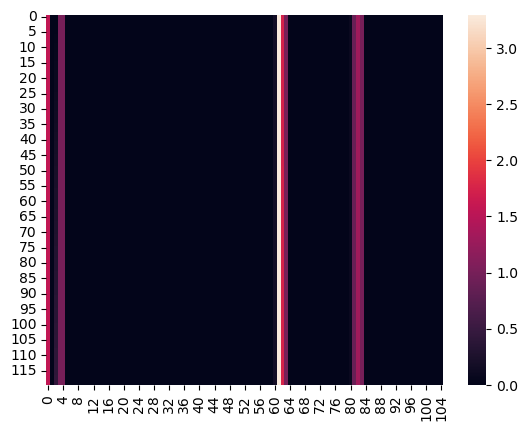

In [106]:
import seaborn as sns
sns.heatmap(med_tensor_sample[5])